In [1]:
%load_ext autoreload
%autoreload 2

from os import path
from glob import glob
import itertools

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import mne

from notifmmn import erputils

rawdir = '../data/raw/'
resultdir = '../data/results/'

triggers = dict(
    S14='BN STD',
    S15='SN DEV',
    S24='SN STD',
    S25='BN DEV',
    S34='CN STD',
    S35='BN DEV',
)

%matplotlib widget

In [2]:
participants = pd.read_csv('participant_details.csv', index_col=0)
delays = participants['Tone_delay'].rename('tone delay')
n100_latencies = pd.read_csv(path.join(resultdir, 'n100_latencies.csv'), index_col=[0, 1])

In [3]:
# list all preprocessed files
# preprocessing involves manual curation, band pass filtering,
# down sampling, removal of eye artifacts, and epoching
files = glob(path.join(rawdir, 'preprocessed', '*'))
print(len(files))
sorted(files)

58


['../data/raw/preprocessed/sub-sd011-epo.fif',
 '../data/raw/preprocessed/sub-sd012-epo.fif',
 '../data/raw/preprocessed/sub-sd013-epo.fif',
 '../data/raw/preprocessed/sub-sd015-epo.fif',
 '../data/raw/preprocessed/sub-sd016-epo.fif',
 '../data/raw/preprocessed/sub-sd017-epo.fif',
 '../data/raw/preprocessed/sub-sd018-epo.fif',
 '../data/raw/preprocessed/sub-sd019-epo.fif',
 '../data/raw/preprocessed/sub-sd020-epo.fif',
 '../data/raw/preprocessed/sub-sd021-epo.fif',
 '../data/raw/preprocessed/sub-sd022-epo.fif',
 '../data/raw/preprocessed/sub-sd023-epo.fif',
 '../data/raw/preprocessed/sub-sd024-epo.fif',
 '../data/raw/preprocessed/sub-sd024_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd025-epo.fif',
 '../data/raw/preprocessed/sub-sd025_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd026-epo.fif',
 '../data/raw/preprocessed/sub-sd027-epo.fif',
 '../data/raw/preprocessed/sub-sd028-epo.fif',
 '../data/raw/preprocessed/sub-sd029-epo.fif',
 '../data/raw/preproce

# Bootstrapping to get uncertainty in ERP peaks

## Code development

In [29]:
def _compute_peak_latency_amplitudes(erps, window, extrema=-1):
    '''
    Computes the peak latency and peak amplitude of a positive or negative peak
    (determined by extrema parameter) within a given window.
    '''
    pls = (extrema*erps.loc[window[0]:window[1]]).idxmax()
    pas = pd.Series([erps[c].loc[t] for c,t in zip(erps.columns, pls)], index=pls.index)
    # peaks at boundaries should not be considered peaks, so we require
    # that peaks are at least 5 ms away fron boundaries of the window
    pls[(pls<window[0]+0.005)|(pls>window[1]-0.005)] = np.nan
    pas[(pls<window[0]+0.005)|(pls>window[1]-0.005)] = np.nan
    return pd.concat(dict(
        PL=pls,
        PA=pas
    ), axis=1)

def _compute_areal_latency_amplitude(erps, window, latency_fractions=[0.25], extrema=-1):
    '''
    Computes the area under curve within the window to obtain the amplitude
    and the times at which the area crosses certain fractions to obtain latency.
    '''
    erps = (erps*extrema).loc[window[0]:window[1]]
    # detrend the ERPs so that end points are both at 0
    erps = erps.apply(lambda c: c - c.iloc[0] - (c.iloc[-1]-c.iloc[0])*np.arange(len(c))/len(c))
    amp = erps.sum()
    cs = erps.cumsum()
    tfs = {'TWMA':amp/len(erps)*extrema}
    for f in latency_fractions:
        tfs[f'FAL_{f}'] = (cs < amp*f).cumsum().idxmax()
    return pd.concat(tfs, axis=1)

def compute_single_erp_scores(erps, window, latency_fractions=[0.25], extrema=-1):
    '''
    Returns the following scores for an ERP waveform derived by averaging the epochs
    1. peak amplitude (of the highest peak in the window) [PA]
    2. peak latency (of the highest peak in the window) [PL]
    3. time-window mean amplitude [TWMA]
    4. fractional area latency [FAL]
    erps is a list of pandas dataframes
    '''
    return pd.concat([
        _compute_peak_latency_amplitudes(erps[0], window, extrema),
        _compute_areal_latency_amplitude(erps[0], window, latency_fractions, extrema)
    ], axis=1)

def compute_dwave_scores(erps, window, latency_fractions=[0.25], picks=None, extrema=-1):
    '''
    Returns the following scores for an ERP difference wave derived by averaging
    the two groups of epochs and subtracting group 1 from group 0
    1. peak amplitude (of the highest peak in the window) [PA]
    2. peak latency (of the highest peak in the window) [PL]
    3. time-window mean amplitude [TWMA]
    4. fractional area latency [FAL]
    '''
    dwave = erps[0] - erps[1]
    return pd.concat([
        _compute_peak_latency_amplitudes(dwave, window, extrema),
        _compute_areal_latency_amplitude(dwave, window, latency_fractions, extrema)
    ], axis=1)

def compute_bootstrapped_scores(epochs, fn, n_iterations, sample_size=None, picks=None, **kwargs):
    '''
    Compute score(s) with SEM by bootstrapping over epochs
    epochs: an instance of epochs, or list of epoch instances when more than one are required (for example for a difference wave)
    fn: the function to be called to evaluate the parameters for each resampling of epochs
    fn must accept a list of epochs as a pandas dataframe (indexed by epoch and time)
    fn must return a set of scores as a pandas series and the list of generated erps for each input epoch
    n_iterations: number of times resampling should be performed
    sample_size: int or list of ints (number of samples to draw in each iteration). default None will use the same number of samples as original epochs instance
    kwargs: arguments to be passed to the function fn
    '''
    if not isinstance(epochs, list):
        epochs = [epochs]
    if sample_size is None:
        sample_size = [len(x) for x in epochs]
    if picks is None:
        picks = epochs[0].columns
    
    # convert epochs to dataframes for faster computation inside the loop
    epochs = [
        e.to_data_frame().drop('condition', axis=1).set_index(['time', 'epoch'])[picks]\
            .unstack('time').T.groupby('time').mean().T for e in epochs
    ]
    erp_list = []
    for e, ss in zip(epochs, sample_size):
        erps = {}
        for itr in range(n_iterations):
            erps[itr] = e.sample(ss, replace=True).mean()
        erp_list.append(pd.concat(erps, axis=1))
    return fn(erp_list, **kwargs), erp_list

def get_erp_sem(epochs, n_iterations, sample_size=None, verifiplot=True, **kwargs):
    '''
    Returns the scores, erps, errors (encountered in each bootstrapped iteration) and figure object (if verifiplot)
    epochs: if single epochs instance, computes single erp scores
            if list of two epochs, computes the scores for the difference wave
    n_iterations: number of bootstrap iterations to run
    sample_size: number of epochs in each bootstrap iteration (defaults to the number of epochs in original epochs)
    verifiplot: setting True (default) will plot the ERPs (or difference waves) across bootstrapped iterations
    kwargs: arguments required for single wave or difference wave score computation
    kwargs include window (tuple), latency_fractions (list, for computing fractional area latencies), picks (to average over), extrema (whether to find minima or maxima)
    '''
    if not isinstance(epochs, list):
        epochs = [epochs]
    if len(epochs)==1:
        scores, erps = compute_bootstrapped_scores(
            epochs, compute_single_erp_scores, n_iterations=n_iterations, sample_size=sample_size, **kwargs
        )
        erps = erps[0]
    elif len(epochs)==2:
        scores, erps = compute_bootstrapped_scores(
            epochs, compute_dwave_scores, n_iterations=n_iterations, sample_size=sample_size, **kwargs
        )
        erps = erps[0] - erps[1]
    else:
        raise ValueError('exactly one or two sets of epochs must be given.')

    f = None
    if verifiplot:
        window = kwargs.pop('window')
        f, ax = plt.subplots(figsize=(8, 3), tight_layout=True)
        erps.plot(ax=ax, c='C0', alpha=0.01, legend=False)
        ax.scatter(scores.PL, scores.PA, s=1, c='k')
        ax.set_xlabel('time (s)')
        ax.set_ylabel('voltage ($\mu V$)')
        ax.axvspan(*window, color='gray', alpha=0.1)
        ax.annotate(
            scores.aggregate(['mean', 'std']).to_string(float_format='{:.3f}'.format, col_space=8, justify='right'),
            (10, 10), xycoords='axes pixels', family='monospace'
        )
    return scores, erps, f

In [25]:
fname = '../data/raw/preprocessed/sub-sd025-epo.fif'
sub = path.basename(fname).split('-')[1]
_epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')

/home/jupyter-saurabh/env-ecf-sst/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


,PL,PA,TWMA,FAL_0.01,FAL_0.25,FAL_0.5,FAL_0.99
0,0.216797,-2.068146,-1.255518,0.185547,0.205078,0.214844,0.244141


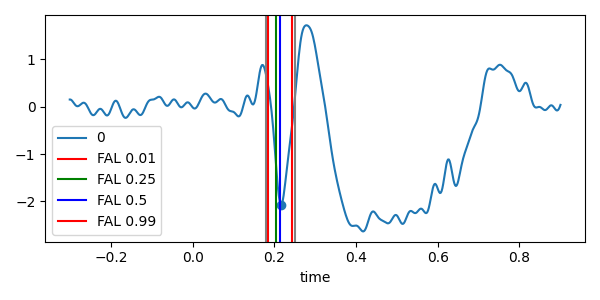

In [30]:
# test the erp_scores function
__epochs = _epochs['S14'].to_data_frame().drop('condition', axis=1).set_index(['time', 'epoch']).mean(axis=1).unstack('time')
__erp = __epochs.mean().to_frame()
window = (0.18, 0.25)

scores = compute_single_erp_scores([__erp], window=window, latency_fractions=[0.01, 0.25, 0.5, 0.99])

f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
__erp.plot(ax=ax)
ax.axvline(window[0], c='gray')
ax.axvline(window[1], c='gray')
ax.scatter([scores['PL']], [scores['PA']])
ax.axvline(scores.loc[0]['FAL_0.01'], c='r', label='FAL 0.01')
ax.axvline(scores.loc[0]['FAL_0.25'], c='g', label='FAL 0.25')
ax.axvline(scores.loc[0]['FAL_0.5'], c='b', label='FAL 0.5')
ax.axvline(scores.loc[0]['FAL_0.99'], c='r', label='FAL 0.99')
ax.legend()

scores

In [31]:
# directly test the bootstrap function
scores, erps = compute_bootstrapped_scores(_epochs['S14'], compute_single_erp_scores, n_iterations=10, window=(0.18, 0.24), picks=['Fz', 'FCz', 'Cz'])

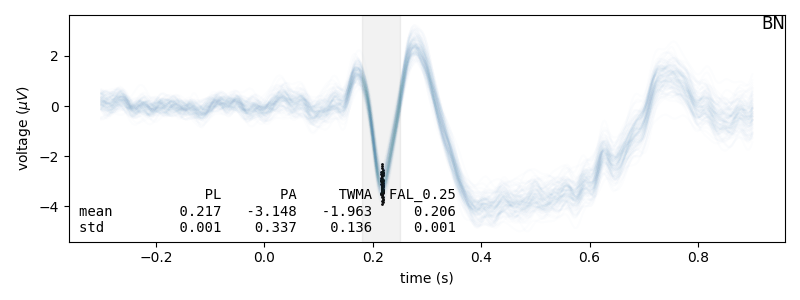

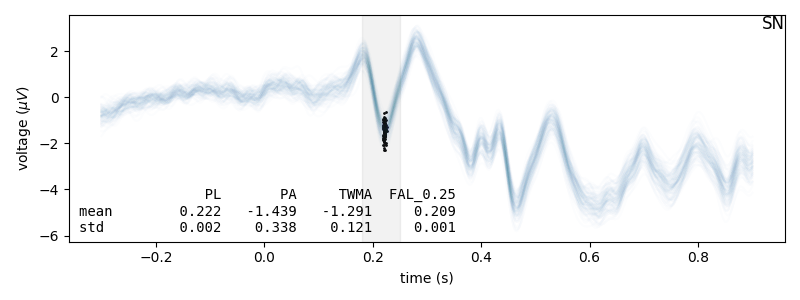

In [32]:
# test bootstrapping function for single ERPs through SEM wrapper
n1_win = (0.18, 0.25)
scores_bn, erps, f_bn = get_erp_sem(_epochs['S14'], n_iterations=100, window=window, picks=['Fz', 'FCz', 'Cz'])
scores_sn, erps, f_sn = get_erp_sem(_epochs['S24'], n_iterations=100, window=window, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right');

/tmp/ipykernel_2736168/782540590.py:121: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f, ax = plt.subplots(figsize=(8, 3), tight_layout=True)


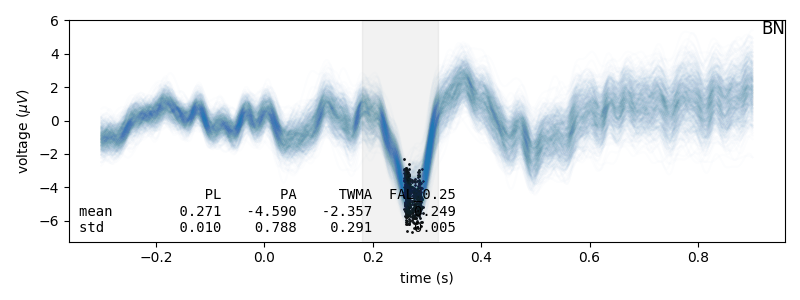

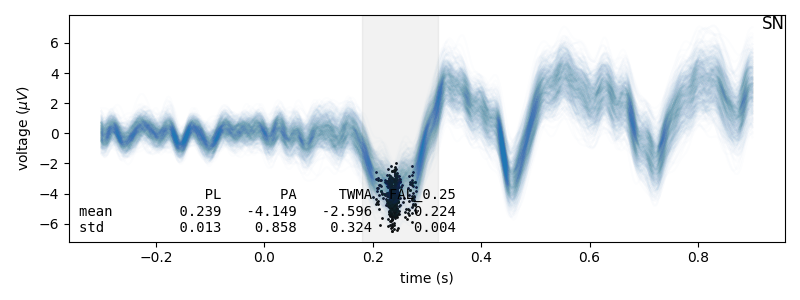

In [33]:
# test bootstrapping function for difference wave (MMN) ERPs
mmn_win = (0.18, 0.32)
scores_bn, erps, f_bn = get_erp_sem([_epochs['S25'], _epochs['S14']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, erps, f_sn = get_erp_sem([_epochs['S15'], _epochs['S24']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right');

## Usage example with library
In the example, only 50 iterations are used to run it faster. However at least 1000 iterations should be used for final analysis.

In [6]:
# load the data
fname = '../data/raw/preprocessed/sub-sd025-epo.fif'
sub = path.basename(fname).split('-')[1]
_epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')

BN scores:


,PL,PA,TWMA,FAL_0.25
mean,0.217223,-3.054849,-1.941366,0.205969
std,0.001190,0.327155,0.133275,0.001042


SN scores:


,PL,PA,TWMA,FAL_0.25
mean,0.221852,-1.408682,-1.300083,0.208660
std,0.001716,0.323860,0.132600,0.001335


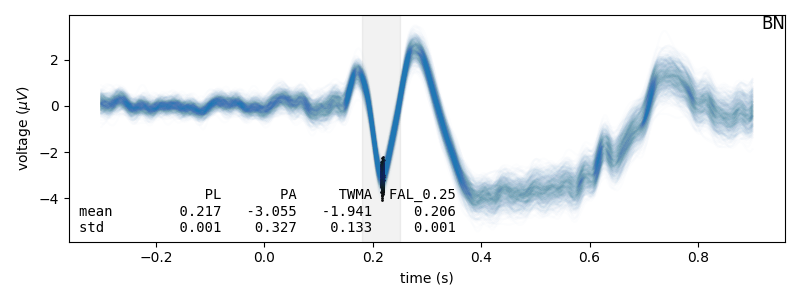

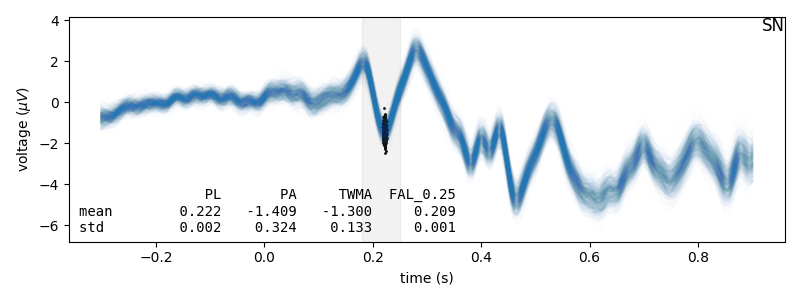

In [7]:
# get N1 scores
# in general N1 windows can be defined between tone_delay + 0.18 to tone_delay+0.24 (seconds)
# tone delays can be read from `participant_details.csv`
n1_win = (0.18, 0.25)
scores_bn, _, f_bn = erputils.get_erp_sem(_epochs['S14'], n_iterations=500, window=n1_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, _, f_sn = erputils.get_erp_sem(_epochs['S24'], n_iterations=500, window=n1_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right')
print('BN scores:')
display(scores_bn.aggregate(['mean', 'std']))
print('SN scores:')
display(scores_sn.aggregate(['mean', 'std']))

BN scores:


,PL,PA,TWMA,FAL_0.25
mean,0.270672,-4.606462,-2.328736,0.248516
std,0.009334,0.832648,0.278292,0.005375


SN scores:


,PL,PA,TWMA,FAL_0.25
mean,0.238449,-4.231946,-2.589561,0.224500
std,0.012991,0.876832,0.330009,0.004383


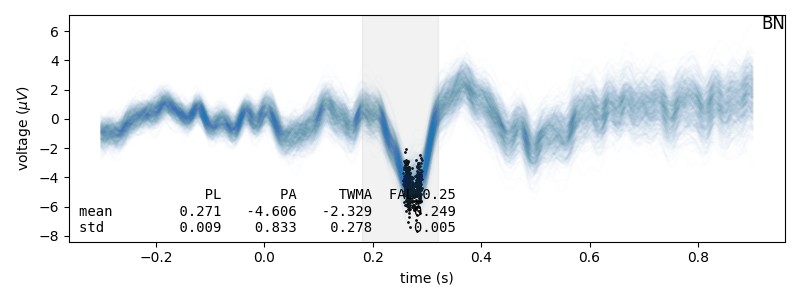

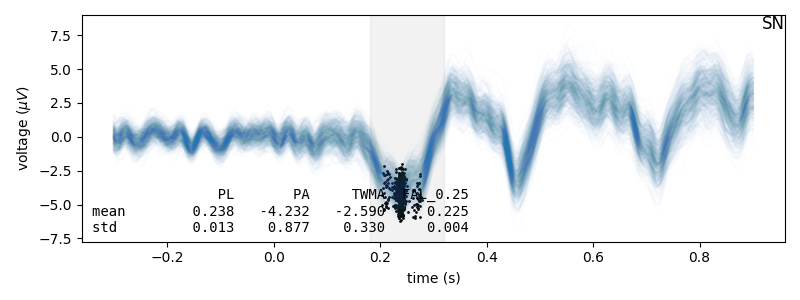

In [10]:
# get MMN scores
# note that latencies have to be adjusted to account for N1 latencies
# the function returns latencies wrt epoch (ie stimulus onset)
mmn_win = (0.18, 0.32)
scores_bn, _, f_bn = erputils.get_erp_sem([_epochs['S25'], _epochs['S14']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, _, f_sn = erputils.get_erp_sem([_epochs['S15'], _epochs['S24']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right')
print('BN scores:')
display(scores_bn.aggregate(['mean', 'std']))
print('SN scores:')
display(scores_sn.aggregate(['mean', 'std']))

# Other things

In [23]:
# dependence on sample size
params = {}
for s in tqdm(np.linspace(1, 40, 40)*50):
    params[s], erps, n_failed, f = erputils.get_bootstrapped_latency_amplitude(
        epochs.loc[('SN', 'STD')][['FCz', 'Fz', 'Cz']].mean(axis=1).unstack('time'),
        sample_size=int(s), n_iterations=1000, approx_latency=0.22, verify_plot=False
    )

  0%|          | 0/40 [00:00<?, ?it/s]

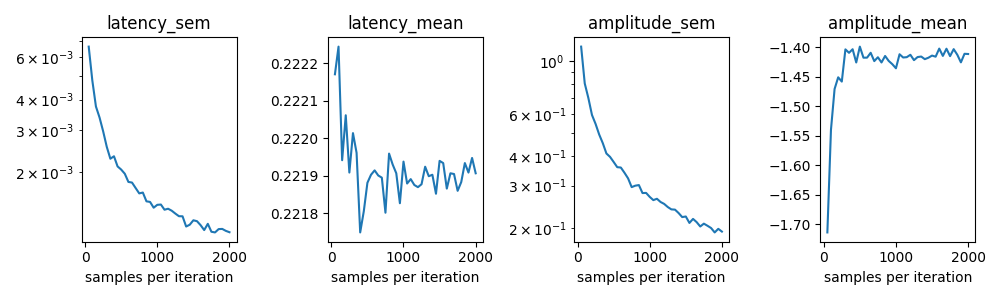

In [24]:
f, axes = plt.subplots(1, 4, figsize=(10, 3), tight_layout=True)
for ax, key in zip(axes, ['latency_sem', 'latency_mean', 'amplitude_sem', 'amplitude_mean']):
    ax.plot(*np.array([(k, params[k][key]) for k in params.keys()]).T)
    ax.set_title(key)
    ax.set_xlabel('samples per iteration')
axes[0].set_yscale('log')
axes[2].set_yscale('log')

Next steps:
- [ ] For each subject with good N1, get mean and SEM of SN and BN N1 latency and amplitude; save it in a csv dataframe.
- [ ] In the scatter plot of tone delay vs N1 latency, include errorbars based on latency MMN (and color the points by tone)
- [ ] For each subject with good N1, get mean and SEM of SN and BN MMN latency and amplitude. Save it in a csv dataframe.
- [ ] Make a scatter plot of BN MMN latency vs SN MMN latency including both x and y errorbars; include a x=y line for reference
- [ ] Make a scatter plot of BN MMN amplitude vs SN MMN amplitude including both x and y errorbars; include a x=y line for reference
- [ ] Other things that make sense to you; I will share more tomorrow